# Fraud Detection — Imbalanced Machine Learning at Scale


**Dataset:** PaySim / Synthetic Financial Datasets for Fraud Detection  
Source: Kaggle — https://www.kaggle.com/datasets/ealaxi/paysim1

### Core question
Can we identify fraudulent transactions reliably in a highly imbalanced, time-ordered dataset while controlling false positives and avoiding data leakage?


## 1. Problem framing

Fraud detection is a **binary supervised classification** problem with a highly imbalanced target.

The primary evaluation question is not simply *"How accurate is the model?"*.

Instead, we evaluate:
- **Recall:** how much fraud we detect
- **Precision:** how many flagged transactions are actually fraud
- **F1:** balance between precision and recall
- **PR-AUC:** performance under severe class imbalance
- **ROC-AUC:** ranking discrimination
- **Confusion matrix:** operational error profile
- **Threshold analysis:** how the decision threshold changes false positives and false negatives

The final threshold should be treated as a decision, not an automatic consequence of using 0.50.


In [5]:
import sys
print(sys.executable)


/opt/anaconda3/envs/geo_env/bin/python


In [6]:
%pip install lightgbm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 828.3 kB/s eta 0:00:00a 0:00:02

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Imports and reproducibility

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from xgboost import XGBClassifier
import lightgbm as lgb

RANDOM_STATE = 42


## 3. Load the data



In [8]:
DATA_PATH = "/Users/user/Desktop/AQA/fraud.csv"   

data = pd.read_csv(DATA_PATH)
data.shape


(6362620, 11)

## 4. Initial data audit

Before modelling, establish:
- number of rows and columns
- data types
- missing values
- structural zeros
- duplicate records
- target distribution
- time range

**Key distinction:** a zero is not automatically a missing value. In this dataset, zero balances can be meaningful transaction states.


In [35]:
data.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


In [9]:
display(data.head())
display(data.dtypes)
display(data.isna().sum().sort_values(ascending=False).head(15))
print("Duplicate rows:", data.duplicated().sum())
print("Shape:", data.shape)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0
Shape: (6362620, 11)


isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud rate: 0.1291%


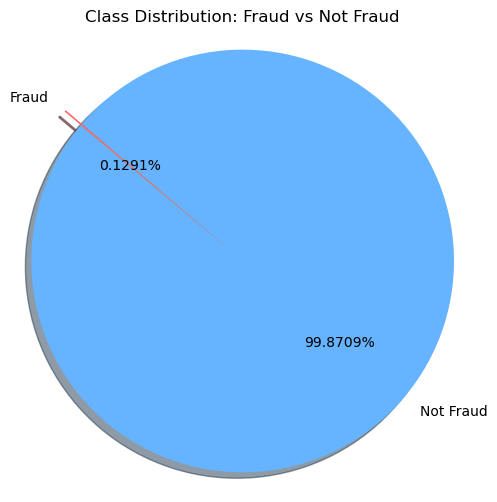

In [11]:
# Class_Imbalance

# Count each class
class_counts = data["isFraud"].value_counts().sort_index()

# Calculate fraud rate
target_rate = data["isFraud"].mean()

# Print class counts and fraud rate
print(class_counts)
print(f"Fraud rate: {target_rate:.4%}")

# Labels and colours
labels = ['Not Fraud', 'Fraud']
colors = ['#66b3ff', '#ff6666']
explode = (0, 0.1)  # Slightly separate the fraud slice for emphasis

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    class_counts,
    labels=labels,
    autopct='%1.4f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True
)

plt.title('Class Distribution: Fraud vs Not Fraud')
plt.axis('equal')
plt.show()


## 5. Data leakage risk assessment


**Allowed:** information available before the current transaction.

**Not allowed:** information from the current or future transaction, including future customer activity.

This is especially important because the dataset is time-ordered.


## 6. Temporal train / validation / test split


**Past → Training → Validation → Future Test**

This better reflects deployment: a model trained on historical transactions should be evaluated on later transactions.

The exact boundaries are defined from the `step` variable rather than hard-coded row positions.

Because transactions are time-ordered, a chronological train-validation-test split was used instead of a random split. This prevents information from future periods from entering the training set and provides a more realistic estimate of how the model would perform when predicting future transactions.


In [15]:
data = data.sort_values("step").reset_index(drop=True)

unique_steps = np.sort(data["step"].unique())
n_steps = len(unique_steps)

train_end = unique_steps[int(n_steps * 0.70) - 1]
val_end = unique_steps[int(n_steps * 0.85) - 1]

train_mask = data["step"] <= train_end
val_mask = (data["step"] > train_end) & (data["step"] <= val_end)
test_mask = data["step"] > val_end

train = data.loc[train_mask].copy()
val = data.loc[val_mask].copy()
test = data.loc[test_mask].copy()

is_sorted = data["step"].is_monotonic_increasing
print("Is data already sorted by step?", is_sorted)


print("Train:", train.shape, "steps:", train["step"].min(), "to", train["step"].max())
print("Validation:", val.shape, "steps:", val["step"].min(), "to", val["step"].max())
print("Test:", test.shape, "steps:", test["step"].min(), "to", test["step"].max())


for name, df in [
    ("Train", train),
    ("Validation", val),
    ("Test", test)
]:
    counts = df["isFraud"].value_counts().sort_index()
    
    fraud_count = counts.get(1, 0)
    non_fraud_count = counts.get(0, 0)
    total = len(df)
    fraud_rate = fraud_count / total

    print(f"\n{name}")
    print(f"Total transactions: {total:,}")
    print(f"Not Fraud:         {non_fraud_count:,}")
    print(f"Fraud:             {fraud_count:,}")
    print(f"Fraud rate:        {fraud_rate:.4%}")




Is data already sorted by step? True
Train: (6082007, 11) steps: 1 to 520
Validation: (191147, 11) steps: 521 to 631
Test: (89466, 11) steps: 632 to 743

Train
Total transactions: 6,082,007
Not Fraud:         6,076,226
Fraud:             5,781
Fraud rate:        0.0951%

Validation
Total transactions: 191,147
Not Fraud:         189,967
Fraud:             1,180
Fraud rate:        0.6173%

Test
Total transactions: 89,466
Not Fraud:         88,214
Fraud:             1,252
Fraud rate:        1.3994%


## 7. Leakage-safe feature engineering

Historical features are rebuilt so that each transaction only uses information available **before that transaction**.

Examples:
- number of previous transactions
- time since previous transaction
- average previous transaction amount
- cumulative previous transaction amount
- balance-change features

We deliberately avoid full-dataset aggregates that include future behaviour.


In [16]:
df = data.copy()
df = df.sort_values(["nameOrig", "step"]).reset_index(drop=True)

g = df.groupby("nameOrig", sort=False)

df["hist_per_sender"] = g.cumcount()
df["prev_step"] = g["step"].shift(1)
df["is_first_txn"] = df["prev_step"].isna().astype(int)
df["time_since_last"] = (df["step"] - df["prev_step"]).fillna(0)

# Historical amount statistics: exclude the current transaction
df["_cum_amount_including_current"] = g["amount"].cumsum()
df["total_past_amount"] = (
    df["_cum_amount_including_current"] - df["amount"]
)

df["AVG_txn_amount"] = np.where(
    df["hist_per_sender"] > 0,
    df["total_past_amount"] / df["hist_per_sender"],
    0
)

df["balance_change"] = df["oldbalanceOrg"] - df["amount"]
df["insufficient_funds"] = (df["oldbalanceOrg"] < df["amount"]).astype(int)

df = df.drop(columns=["_cum_amount_including_current"])


# Check corrolation after feature engineering


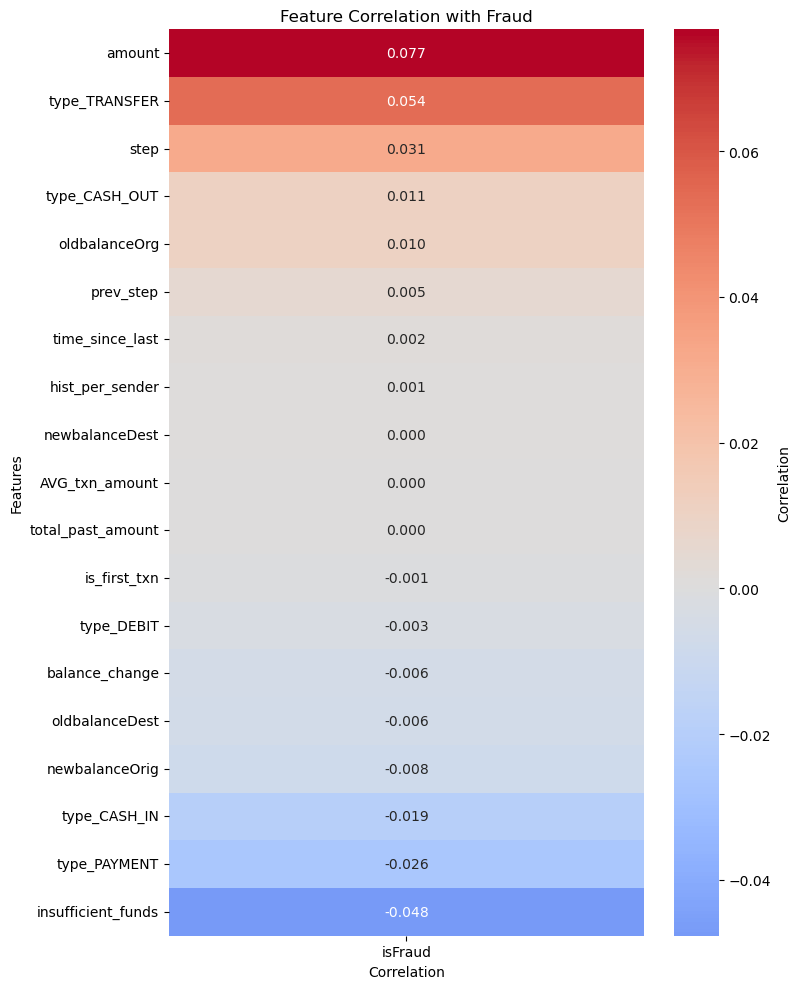

In [36]:
# Features to inspect for correlation with the target
corr_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "prev_step",
    "hist_per_sender",
    "time_since_last",
    "AVG_txn_amount",
    "total_past_amount",
    "balance_change",
    "insufficient_funds",
    "is_first_txn"
]

# Use the training set only for correlation analysis
corr_df = df.loc[train_mask, corr_features + ["isFraud"]].copy()

# One-hot encode the categorical variable "type"
corr_df = pd.get_dummies(
    corr_df,
    columns=["type"],
    dtype=int
)

# Calculate correlations with isFraud
corr = (
    corr_df
    .corr(numeric_only=True)["isFraud"]
    .drop("isFraud")
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 10))

sns.heatmap(
    corr.to_frame(),
    center=0,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


## 8. Transaction-type encoding

For tree models, we can use a one-hot encoded transaction type rather than an arbitrary integer ordering.

The encoder is fitted only on the training data.


In [17]:
feature_cols = [
    "step", "type", "amount",
    "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest",
    "hist_per_sender", "time_since_last",
    "AVG_txn_amount", "total_past_amount",
    "balance_change", "insufficient_funds",
    "is_first_txn"
]

X = df[feature_cols].copy()
y = df["isFraud"].copy()

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val = X.loc[val_mask], y.loc[val_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

categorical_features = ["type"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


## 9. Baseline — Logistic Regression

A simple baseline gives us a reference point before using more complex models.

Because fraud is rare, class weighting is used rather than relying on the default class balance.


In [18]:
baseline = Pipeline([
    ("preprocess", preprocessor),
    ("scale", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)
baseline_val_prob = baseline.predict_proba(X_val)[:, 1]


## 10. Tree-based models

I compare:
1. **Logistic Regression** — interpretable baseline
2. **XGBoost** — nonlinear boosted trees
3. **LightGBM** — efficient gradient boosting for large tabular data

The purpose is not to test as many models as possible, but to understand whether increased model complexity produces meaningful gains under the relevant metrics.


In [19]:
train_fraud = y_train.sum()
train_nonfraud = (y_train == 0).sum()
scale_pos_weight = train_nonfraud / train_fraud

xgb_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]


In [20]:
# LightGBM receives the same leakage-safe feature set.
# Categorical 'type' is encoded through the same preprocessing pipeline for comparability.

lgbm_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ))
])

lgbm_model.fit(X_train, y_train)
lgbm_val_prob = lgbm_model.predict_proba(X_val)[:, 1]


## 11. Evaluation function

Accuracy is deliberately not used as the primary selection metric.

I report ROC-AUC and PR-AUC for ranking quality, then precision, recall and F1 at a defined decision threshold.


In [21]:
def evaluate_probabilities(y_true, prob, threshold=0.5, name="model"):
    pred = (prob >= threshold).astype(int)
    return {
        "model": name,
        "threshold": threshold,
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "false_positives": confusion_matrix(y_true, pred)[0, 1],
        "false_negatives": confusion_matrix(y_true, pred)[1, 0],
    }

results = pd.DataFrame([
    evaluate_probabilities(y_val, baseline_val_prob, name="Logistic Regression"),
    evaluate_probabilities(y_val, xgb_val_prob, name="XGBoost"),
    evaluate_probabilities(y_val, lgbm_val_prob, name="LightGBM"),
])

results.sort_values("pr_auc", ascending=False)


,model,threshold,precision,recall,f1,roc_auc,pr_auc,false_positives,false_negatives
2,LightGBM,0.5,0.996350,0.996350,0.996350,0.999923,0.996582,1,1
1,XGBoost,0.5,0.847352,0.992701,0.914286,0.999983,0.992716,49,2
0,Logistic Regression,0.5,0.032159,0.996350,0.062307,0.995303,0.656272,8216,1


## 12. Precision–Recall analysis and threshold selection

A threshold of 0.50 is not automatically optimal.

For a fraud-screening system, the threshold should reflect the relative cost of:
- missing a fraudulent transaction
- incorrectly flagging a legitimate customer

I use the validation set to explore this trade-off. The test set remains untouched until the final evaluation.


In [22]:
def threshold_table(y_true, prob, thresholds=np.arange(0.05, 1.00, 0.05)):
    rows = []
    for t in thresholds:
        pred = (prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

lgbm_thresholds = threshold_table(y_val, lgbm_val_prob)
lgbm_thresholds


,threshold,precision,recall,f1
0,0.05,0.954545,0.99635,0.975000
1,0.10,0.975000,0.99635,0.985560
2,0.15,0.978495,0.99635,0.987342
3,0.20,0.982014,0.99635,0.989130
4,0.25,0.982014,0.99635,0.989130
5,0.30,0.989130,0.99635,0.992727
6,0.35,0.992727,0.99635,0.994536
7,0.40,0.996350,0.99635,0.996350
8,0.45,0.996350,0.99635,0.996350
9,0.50,0.996350,0.99635,0.996350


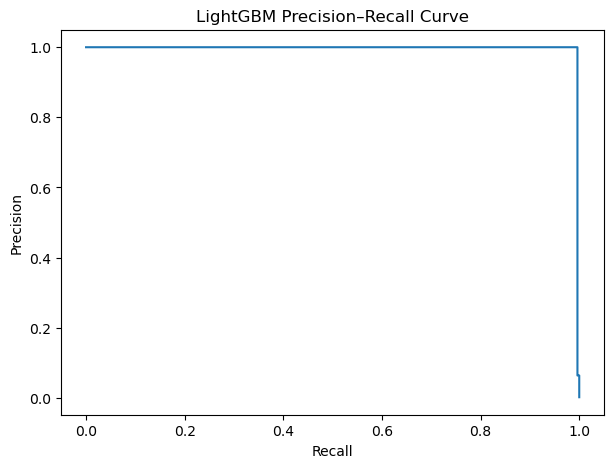

In [23]:
precision, recall, thresholds = precision_recall_curve(y_val, lgbm_val_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LightGBM Precision–Recall Curve")
plt.show()


## 13. Final model selection

Select the model and operating threshold using the **validation set** and an explicit decision criterion.

> *"I selected LightGBM based on its validation performance, prioritising PR-AUC and recall because fraud is rare and missing fraud is costly. I also considered precision and false positives because too many false alarms can create unnecessary investigation workload. LightGBM provided the best overall balance at the 0.5 threshold, with 99.64% precision and recall and only 1 false positive and 1 false negative."*


In [29]:
# Example selection criterion — adjust after inspecting validation results.
# Here we choose the LightGBM threshold with the highest F1 as a neutral starting point.
best_row = lgbm_thresholds.loc[lgbm_thresholds["f1"].idxmax()]
best_threshold = float(best_row["threshold"])

print("Selected threshold:", best_threshold)
print(best_row)


Selected threshold: 0.9500000000000001
threshold    0.950000
precision    1.000000
recall       0.996350
f1           0.998172
Name: 18, dtype: float64


## 14. Final evaluation on the unseen future test set

The test set is used only once the model and threshold have been selected.

This provides a more realistic estimate of performance on later transactions.


In [25]:
final_test_prob = lgbm_model.predict_proba(X_test)[:, 1]

final_metrics = evaluate_probabilities(
    y_test,
    final_test_prob,
    threshold=best_threshold,
    name="LightGBM — final test"
)

pd.DataFrame([final_metrics])


,model,threshold,precision,recall,f1,roc_auc,pr_auc,false_positives,false_negatives
0,LightGBM — final test,0.95,1.0,1.0,1.0,1.0,1.0,0,0


Confusion matrix:
[[89337     0]
 [    0   129]]

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     89337
           1     1.0000    1.0000    1.0000       129

    accuracy                         1.0000     89466
   macro avg     1.0000    1.0000    1.0000     89466
weighted avg     1.0000    1.0000    1.0000     89466

Confusion matrix:
[[89337     0]
 [    0   129]]

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     89337
           1     1.0000    1.0000    1.0000       129

    accuracy                         1.0000     89466
   macro avg     1.0000    1.0000    1.0000     89466
weighted avg     1.0000    1.0000    1.0000     89466



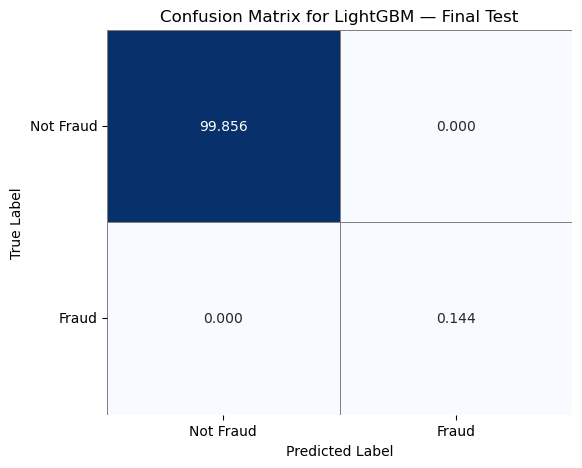

array([[89337,     0],
       [    0,   129]])

In [31]:
cm = confusion_matrix(y_test, (final_test_prob >= best_threshold).astype(int))

print("Confusion matrix:")
print(cm)
print()
print(classification_report(
    y_test,
    (final_test_prob >= best_threshold).astype(int),
    digits=4,
    zero_division=0
))


cm = confusion_matrix(y_test, (final_test_prob >= best_threshold).astype(int))

print("Confusion matrix:")
print(cm)
print()
print(classification_report(
    y_test,
    (final_test_prob >= best_threshold).astype(int),
    digits=4,
    zero_division=0
))


# Calculate percentages for each cell
cm_percent = cm / cm.sum() * 100  # Percentage of total samples

plt.figure(figsize=(6, 5))

# Plot heatmap with percentage annotations
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.3f',                # Three decimal places
    cmap='Blues',
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.xticks(
    ticks=[0.5, 1.5],
    labels=['Not Fraud', 'Fraud']
)

plt.yticks(
    ticks=[0.5, 1.5],
    labels=['Not Fraud', 'Fraud'],
    rotation=0
)

plt.title('Confusion Matrix for LightGBM — Final Test')

plt.show()

cm



## 15. Error analysis

Aggregate metrics do not tell us **where** the model fails.

We inspect:
- false positives
- false negatives
- transaction type
- transaction amount
- time period
- balance behaviour

This helps identify systematic failure modes and possible feature improvements.


In [32]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["probability"] = final_test_prob
error_analysis["prediction"] = (final_test_prob >= best_threshold).astype(int)

false_positives = error_analysis[
    (error_analysis["actual"] == 0) & (error_analysis["prediction"] == 1)
]
false_negatives = error_analysis[
    (error_analysis["actual"] == 1) & (error_analysis["prediction"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

display(false_negatives.head(20))


False positives: 0
False negatives: 0


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,hist_per_sender,time_since_last,AVG_txn_amount,total_past_amount,balance_change,insufficient_funds,is_first_txn,actual,probability,prediction


## 16. Explainability — SHAP

For the final tree model, SHAP can be used to investigate:
- global feature importance
- direction and magnitude of feature contributions
- individual predictions

The goal is not merely to produce a feature-importance chart, but to answer:
> **Why did the model consider this transaction high risk?**

This is particularly useful when models support consequential decisions.


  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 2.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 2.2 MB/s eta 0:00:00-:--:--
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Top 20 features by mean absolute SHAP value:


,feature,mean_abs_shap
16,cat__type_PAYMENT,0.586967
0,num__step,0.496547
13,cat__type_CASH_IN,0.252261
10,num__balance_change,0.249414
5,num__newbalanceDest,0.225532
2,num__oldbalanceOrg,0.209182
4,num__oldbalanceDest,0.170150
3,num__newbalanceOrig,0.153505
11,num__insufficient_funds,0.152205
1,num__amount,0.148413


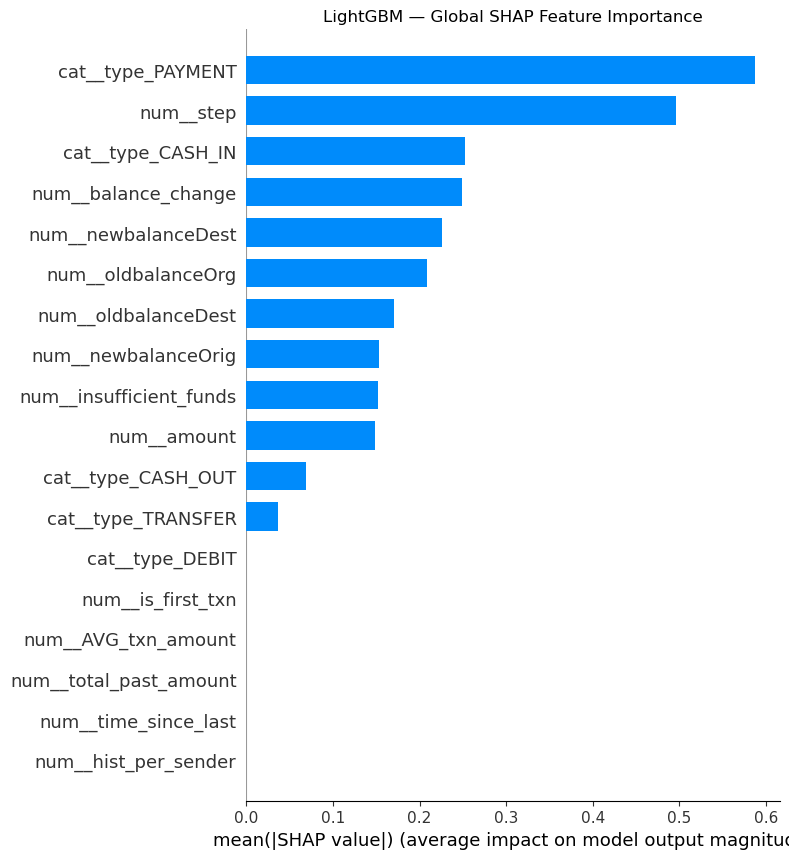

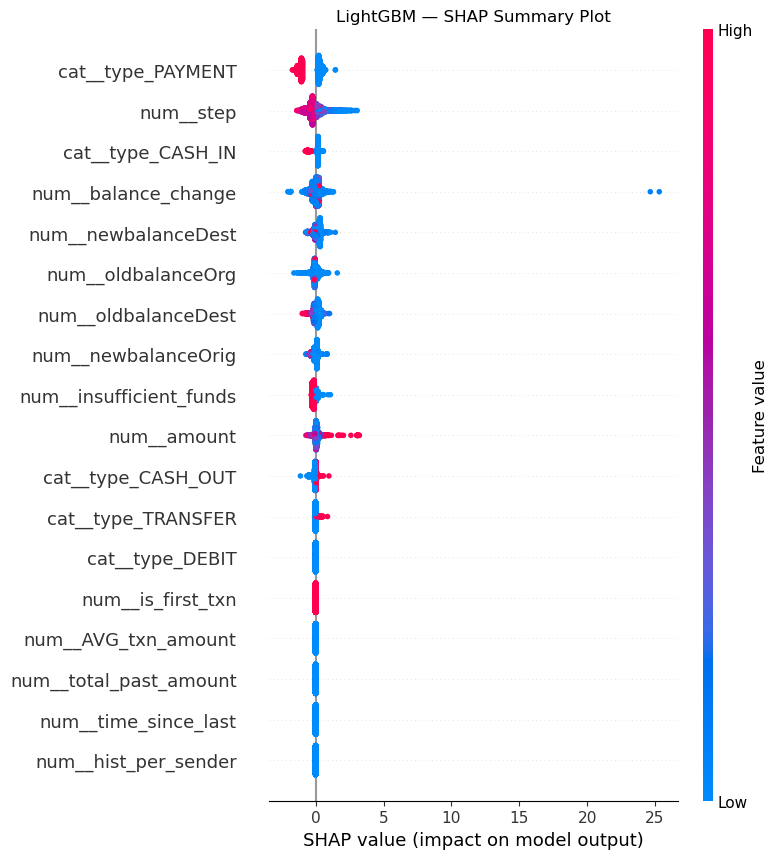

In [ ]:
%pip install shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Extract the fitted preprocessing and LightGBM model
# ---------------------------------------------------------

fitted_preprocessor = lgbm_model.named_steps["preprocess"]
fitted_model = lgbm_model.named_steps["model"]


# ---------------------------------------------------------
# 2. Take a representative sample of the test set
# ---------------------------------------------------------
# PaySim is large, so we don't need to calculate SHAP
# values for every test transaction.

SHAP_SAMPLE_SIZE = 2000

X_test_shap = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=RANDOM_STATE
)


# ---------------------------------------------------------
# 3. Transform the test data using the fitted preprocessor
# ---------------------------------------------------------

X_test_shap_transformed = fitted_preprocessor.transform(X_test_shap)


# ---------------------------------------------------------
# 4. Get feature names after preprocessing
# ---------------------------------------------------------

feature_names = fitted_preprocessor.get_feature_names_out()


# ---------------------------------------------------------
# 5. Create the SHAP TreeExplainer
# ---------------------------------------------------------

explainer = shap.TreeExplainer(fitted_model)

shap_values = explainer.shap_values(
    X_test_shap_transformed
)


# ---------------------------------------------------------
# 6. Handle different SHAP versions
# ---------------------------------------------------------
# For binary classification, some SHAP versions return:
# [SHAP values for class 0, SHAP values for class 1]
# while newer versions may return a single array.

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values


# ---------------------------------------------------------
# 7. Global feature importance — mean absolute SHAP value
# ---------------------------------------------------------

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_plot).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

print("Top 20 features by mean absolute SHAP value:")
display(shap_importance.head(20))


# ---------------------------------------------------------
# 8. Global SHAP importance plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_plot,
    X_test_shap_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("LightGBM — Global SHAP Feature Importance")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 9. SHAP beeswarm plot
# ---------------------------------------------------------
# This shows both importance and direction of the effect.

shap.summary_plot(
    shap_values_plot,
    X_test_shap_transformed,
    feature_names=feature_names,
    show=False
)

plt.title("LightGBM — SHAP Summary Plot")
plt.tight_layout()
plt.show()
